# Scube1 Expression Across Basal Ganglia Regions (10x snRNA-seq)

Compare Scube1 expression across three basal ganglia parcellations from the
Allen Brain Cell Atlas WMB-10X dataset:

- **STRd** — Dorsal striatum (caudate-putamen)
- **STRv** — Ventral striatum (nucleus accumbens)
- **PAL** — Pallidum (globus pallidus external/internal, ventral pallidum)

### Gene Panel (12 genes)
- **Scube1**: Signal peptide, CUB and EGF-like domain-containing protein 1
- **MSN markers**: Drd1 (D1), Drd2 (D2), Adora2a (indirect pathway), Ppp1r1b (DARPP-32)
- **Interneuron markers**: Chat (cholinergic), Sst (somatostatin), Pvalb (parvalbumin)
- **Neurotransmitter markers**: Gad1, Gad2 (GABAergic), Slc17a7 (glutamatergic), Th (catecholaminergic)

In [1]:
import pandas as pd
import numpy as np
import re
import os
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Load Pre-extracted Expression Data

In [2]:
regions = {
    'STRd': ('strd_scube1_expression.csv', 'strd_scube1_metadata.csv'),
    'STRv': ('strv_scube1_expression.csv', 'strv_scube1_metadata.csv'),
    'PAL':  ('pal_scube1_expression.csv',  'pal_scube1_metadata.csv'),
}

expr_all = {}
meta_all = {}

for region, (expr_f, meta_f) in regions.items():
    if not os.path.exists(expr_f):
        print(f'WARNING: {expr_f} not found — run extract_{region.lower()}_scube1_expression.py first')
        continue
    expr = pd.read_csv(expr_f, index_col=0)
    meta = pd.read_csv(meta_f, index_col=0)
    expr_all[region] = expr
    meta_all[region] = meta
    print(f'{region}: {expr.shape[0]:,} cells x {expr.shape[1]} genes')

target_genes = list(list(expr_all.values())[0].columns)
print(f'\nGenes: {target_genes}')
print(f'Regions loaded: {list(expr_all.keys())}')

STRd: 55,626 cells x 12 genes
STRv: 53,573 cells x 12 genes


PAL: 108,046 cells x 12 genes

Genes: ['Scube1', 'Drd1', 'Drd2', 'Adora2a', 'Ppp1r1b', 'Chat', 'Sst', 'Pvalb', 'Gad1', 'Gad2', 'Slc17a7', 'Th']
Regions loaded: ['STRd', 'STRv', 'PAL']


In [3]:
gene_groups = {
    'Gene of interest': ['Scube1'],
    'MSN markers': ['Drd1', 'Drd2', 'Adora2a', 'Ppp1r1b'],
    'Interneuron': ['Chat', 'Sst', 'Pvalb'],
    'NT markers': ['Gad1', 'Gad2', 'Slc17a7', 'Th'],
}
gene_groups = {k: [g for g in v if g in target_genes] for k, v in gene_groups.items()}
gene_groups = {k: v for k, v in gene_groups.items() if v}

## 2. Cell Type Composition by Region

In [4]:
def clean_name(x):
    return re.sub(r'^\d+\s+', '', str(x))

for region in expr_all:
    meta = meta_all[region].loc[expr_all[region].index].copy()
    meta['subclass_short'] = meta['subclass'].apply(clean_name)
    meta_all[region] = meta
    
    sc_counts = meta.groupby('subclass_short', observed=True).size().sort_values(ascending=False)
    print(f'\n{"=" * 60}')
    print(f'{region}: {len(meta):,} cells, {len(sc_counts)} subclasses')
    print(f'{"=" * 60}')
    for sc_name, cnt in sc_counts.items():
        if cnt >= 20:
            nt = meta[meta['subclass_short'] == sc_name]['neurotransmitter'].mode()
            nt_str = nt.iloc[0] if len(nt) > 0 else ''
            print(f'  {sc_name}: {cnt:,} ({nt_str})')


STRd: 55,626 cells, 52 subclasses
  STR D2 Gaba: 18,139 (GABA)
  STR D1 Gaba: 16,660 (GABA)
  Astro-TE NN: 6,190 ()
  Oligo NN: 3,633 ()
  Microglia NN: 2,277 ()
  Endo NN: 1,811 ()
  OB-STR-CTX Inh IMN: 1,642 (GABA)
  OPC NN: 1,331 ()
  STR D1 Sema5a Gaba: 780 (GABA)
  Peri NN: 556 ()
  STR-PAL Chst9 Gaba: 437 (GABA)
  STR Prox1 Lhx6 Gaba: 367 (GABA)
  SMC NN: 284 ()
  Sst Chodl Gaba: 230 (GABA)
  STR Lhx8 Gaba: 178 (GABA)
  L6 CT CTX Glut: 172 (Glut)
  VLMC NN: 148 ()
  L6 IT CTX Glut: 116 (Glut)
  Astro-NT NN: 111 ()
  BAM NN: 110 ()
  OB-in Frmd7 Gaba: 77 (GABA)
  LA-BLA-BMA-PA Glut: 76 (Glut)
  Ependymal NN: 59 ()
  IT EP-CLA Glut: 37 (Glut)
  PAL-STR Gaba-Chol: 30 (Chol)
  OB-out Frmd7 Gaba: 30 (GABA)

STRv: 53,573 cells, 74 subclasses
  STR D1 Gaba: 12,350 (GABA)
  STR D2 Gaba: 11,148 (GABA)
  OT D3 Folh1 Gaba: 7,665 (GABA)


  Astro-TE NN: 5,989 (Glut)
  STR D1 Sema5a Gaba: 2,707 (GABA)
  Oligo NN: 2,588 ()
  OPC NN: 1,700 ()
  Microglia NN: 1,686 ()
  Endo NN: 1,566 ()
  STR-PAL Chst9 Gaba: 1,349 (GABA)
  OB-STR-CTX Inh IMN: 1,083 (GABA)
  STR Prox1 Lhx6 Gaba: 412 (GABA)
  Peri NN: 363 ()
  Sst Chodl Gaba: 335 (GABA)
  STR Lhx8 Gaba: 326 (GABA)
  ACB-BST-FS D1 Gaba: 305 (GABA)
  SMC NN: 204 ()
  Astro-NT NN: 168 ()
  IT AON-TT-DP Glut: 164 (Glut)
  BAM NN: 157 ()
  VLMC NN: 139 ()
  OB-in Frmd7 Gaba: 113 (GABA)
  SI-MA-LPO-LHA Skor1 Glut: 105 (Glut)
  NDB-SI-ant Prdm12 Gaba: 96 (GABA)
  L6 CT CTX Glut: 80 (Glut)
  PAL-STR Gaba-Chol: 77 (Chol)
  CEA-AAA-BST Six3 Sp9 Gaba: 65 (GABA)
  OB Meis2 Thsd7b Gaba: 52 (GABA)
  Vip Gaba: 51 (GABA)
  HPF CR Glut: 51 (Glut)
  Lamp5 Gaba: 45 (GABA)
  SI-MA-ACB Ebf1 Bnc2 Gaba: 44 (GABA)
  OB-out Frmd7 Gaba: 42 (GABA)
  LSX Prdm12 Slit2 Gaba: 39 (GABA)
  OB Dopa-Gaba: 29 (GABA)
  IA Mgp Gaba: 20 (GABA)



PAL: 108,046 cells, 130 subclasses
  Oligo NN: 26,596 ()
  Astro-NT NN: 8,066 ()


  OPC NN: 6,439 ()
  STR D1 Gaba: 5,851 (GABA)
  NDB-SI-MA-STRv Lhx8 Gaba: 5,327 (GABA)
  STR D2 Gaba: 4,970 (GABA)
  STR-PAL Chst9 Gaba: 4,603 (GABA)
  OT D3 Folh1 Gaba: 4,471 (GABA)
  SI-MA-LPO-LHA Skor1 Glut: 3,353 (Glut)
  STR D1 Sema5a Gaba: 3,109 (GABA)
  Microglia NN: 2,992 ()
  Astro-TE NN: 2,284 ()
  Endo NN: 2,224 ()
  CEA-BST Ebf1 Pdyn Gaba: 1,761 (GABA)
  ACB-BST-FS D1 Gaba: 1,578 (GABA)
  SI-MA-ACB Ebf1 Bnc2 Gaba: 1,164 (GABA)
  CEA-AAA-BST Six3 Sp9 Gaba: 1,155 (GABA)
  GPe-SI Sox6 Cyp26b1 Gaba: 1,106 (GABA)
  MEA-BST Lhx6 Sp9 Gaba: 1,088 (GABA)
  SI-MPO-LPO Lhx8 Gaba: 1,071 (GABA)
  CEA-BST Six3 Cyp26b1 Gaba: 1,019 (GABA)
  MEA-BST Lhx6 Nfib Gaba: 1,007 (GABA)
  MPO-ADP Lhx8 Gaba: 1,002 (GABA)
  NDB-SI-ant Prdm12 Gaba: 985 (GABA)
  Sst Chodl Gaba: 960 (GABA)
  MEA-BST Sox6 Gaba: 896 (GABA)
  BST-MPN Six3 Nrgn Gaba: 799 (GABA)
  PAL-STR Gaba-Chol: 784 (Chol)
  BST Tac2 Gaba: 705 (GABA)
  STR Lhx8 Gaba: 684 (GABA)
  PVR Six3 Sox3 Gaba: 605 (GABA)
  TRS-BAC Sln Glut: 602 (Gl

  VLMC NN: 173 ()
  CEA-BST Gal Avp Gaba: 172 (GABA)
  LHA Barhl2 Glut: 167 (Glut)
  Vip Gaba: 152 (GABA)
  LHA-AHN-PVH Otp Trh Glut: 144 (Glut)
  BAM NN: 139 ()
  LSX Prdm12 Slit2 Gaba: 119 (GABA)
  ZI Pax6 Gaba: 108 (GABA)
  MEA Slc17a7 Glut: 97 (Glut)
  COAa-PAA-MEA Barhl2 Glut: 96 (Glut)
  IA Mgp Gaba: 96 (GABA)
  Tanycyte NN: 92 ()
  Lamp5 Gaba: 91 (GABA)
  MPN-MPO-PVpo Hmx2 Glut: 85 (Glut)
  LSX Sall3 Lmo1 Gaba: 84 (GABA)
  LHA-MEA Otp Glut: 82 (Glut)
  HY Gnrh1 Glut: 76 (Glut)
  BST-po Iigp1 Glut: 73 (Glut)
  OB Dopa-Gaba: 69 (GABA)
  Astroependymal NN: 68 ()
  LSX Sall3 Pax6 Gaba: 64 (GABA)
  HPF CR Glut: 61 (Glut)
  LSX Prdm12 Zeb2 Gaba: 59 (GABA)
  Sst Gaba: 49 (GABA)
  OB Meis2 Thsd7b Gaba: 48 (GABA)
  AHN-RCH-LHA Otp Fezf1 Glut: 42 (Glut)
  DMH-LHA Gsx1 Gaba: 42 (GABA)
  L2/3 IT PIR-ENTl Glut: 41 (Glut)
  Ependymal NN: 38 ()
  PVH-SO-PVa Otp Glut: 37 (Glut)
  LGv-ZI Otx2 Gaba: 36 (GABA)
  CHOR NN: 36 (Glut)
  OB-STR-CTX Inh IMN: 36 (GABA)
  SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glu

## 3. Dot Plot: Scube1 + Markers by Subclass — Each Region

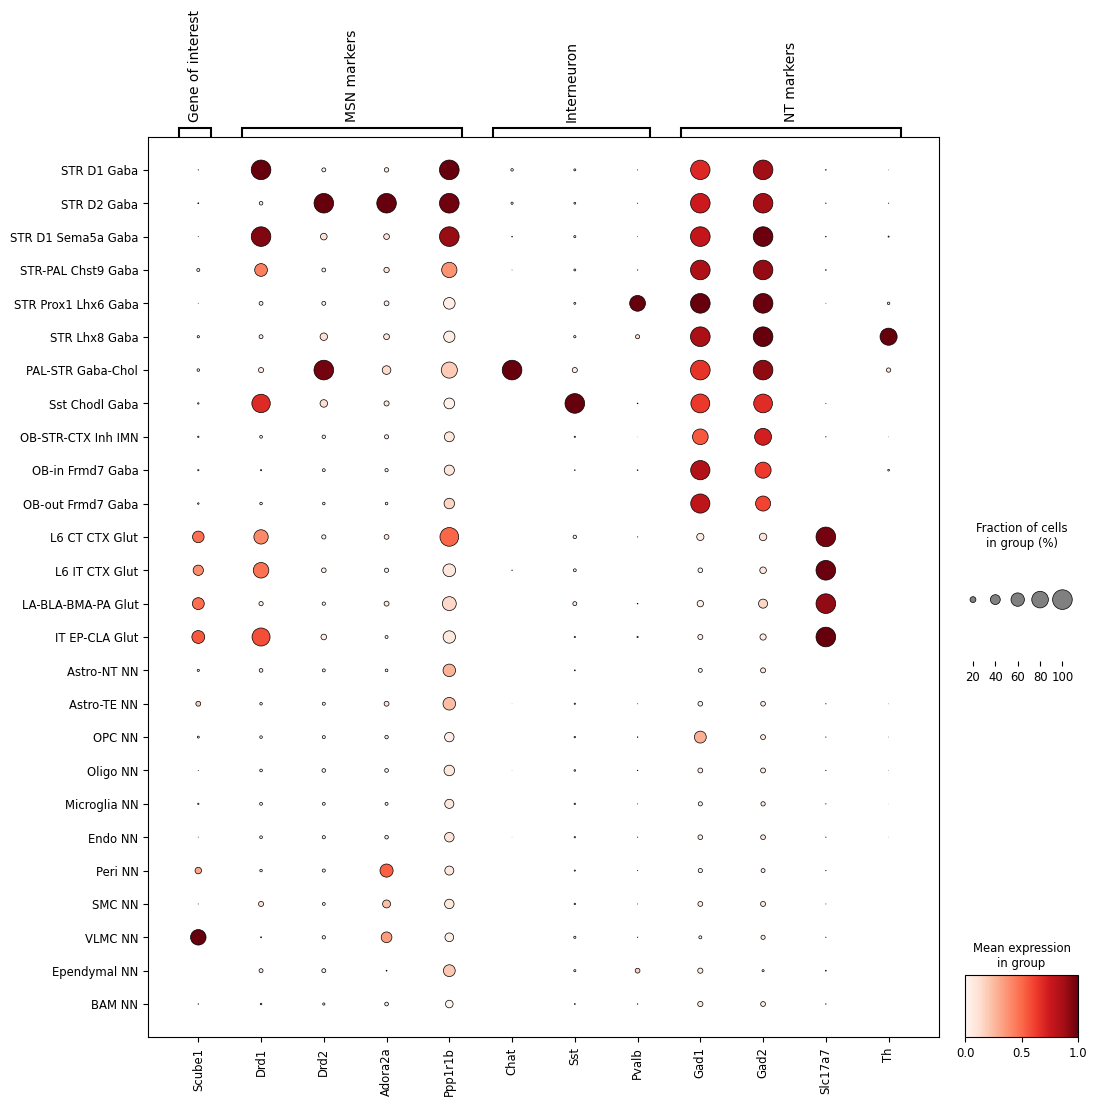

Saved: dotplot_STRd_Scube1_by_subclass.png



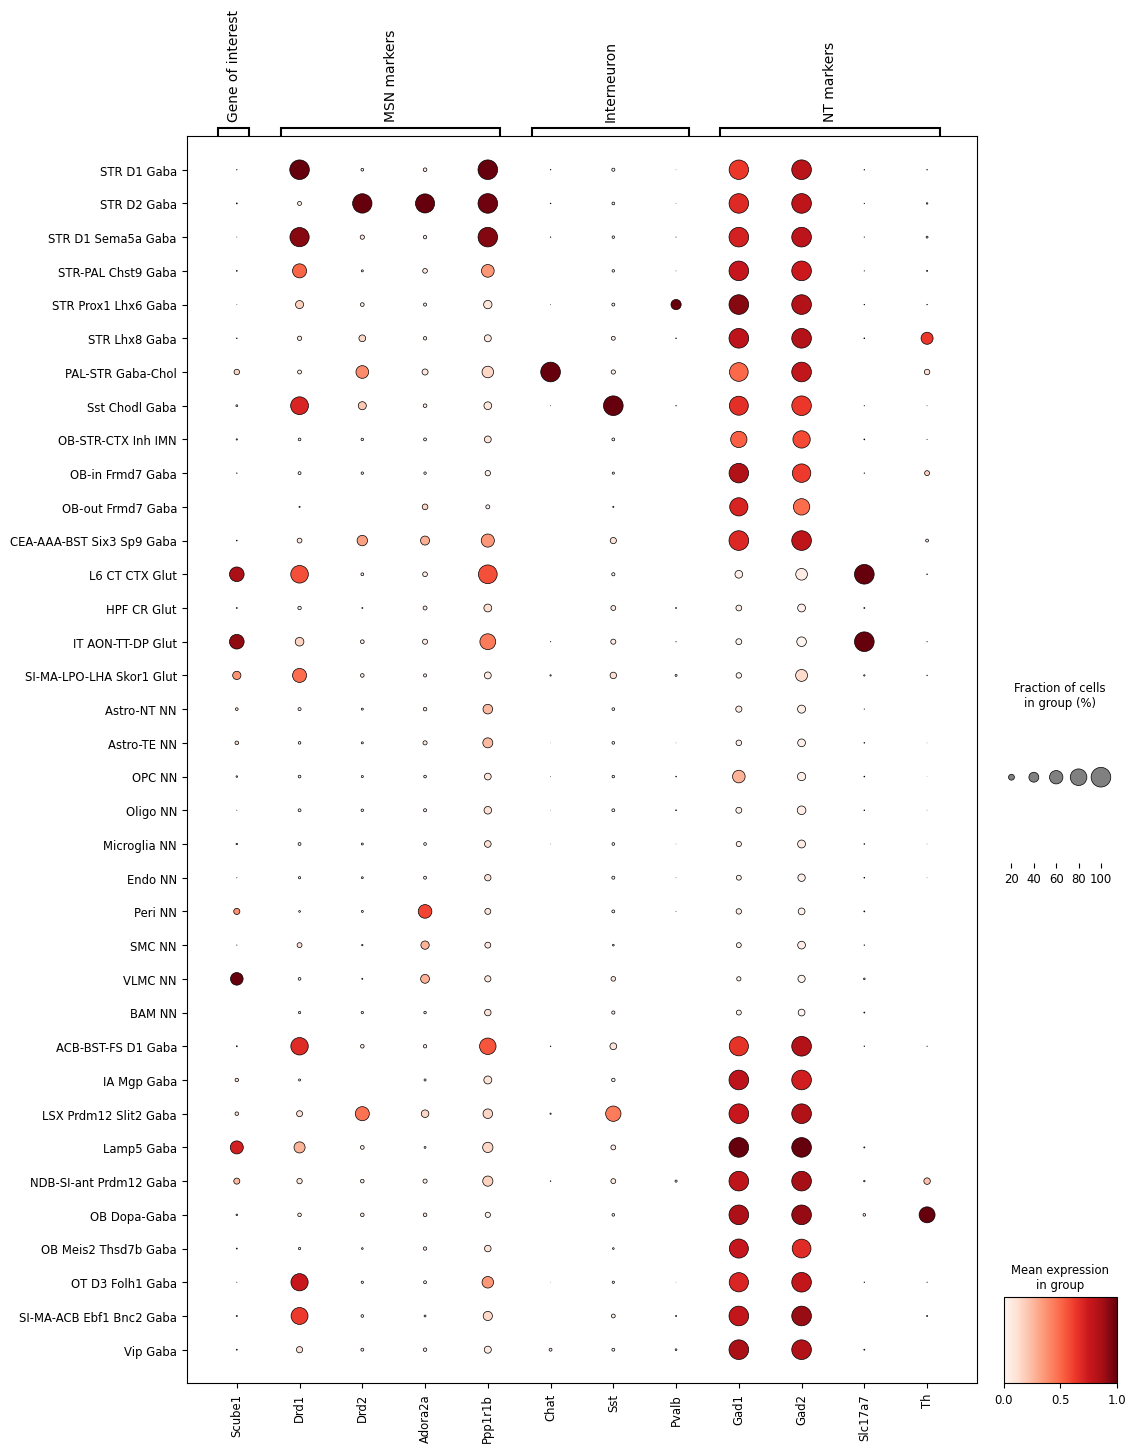

Saved: dotplot_STRv_Scube1_by_subclass.png



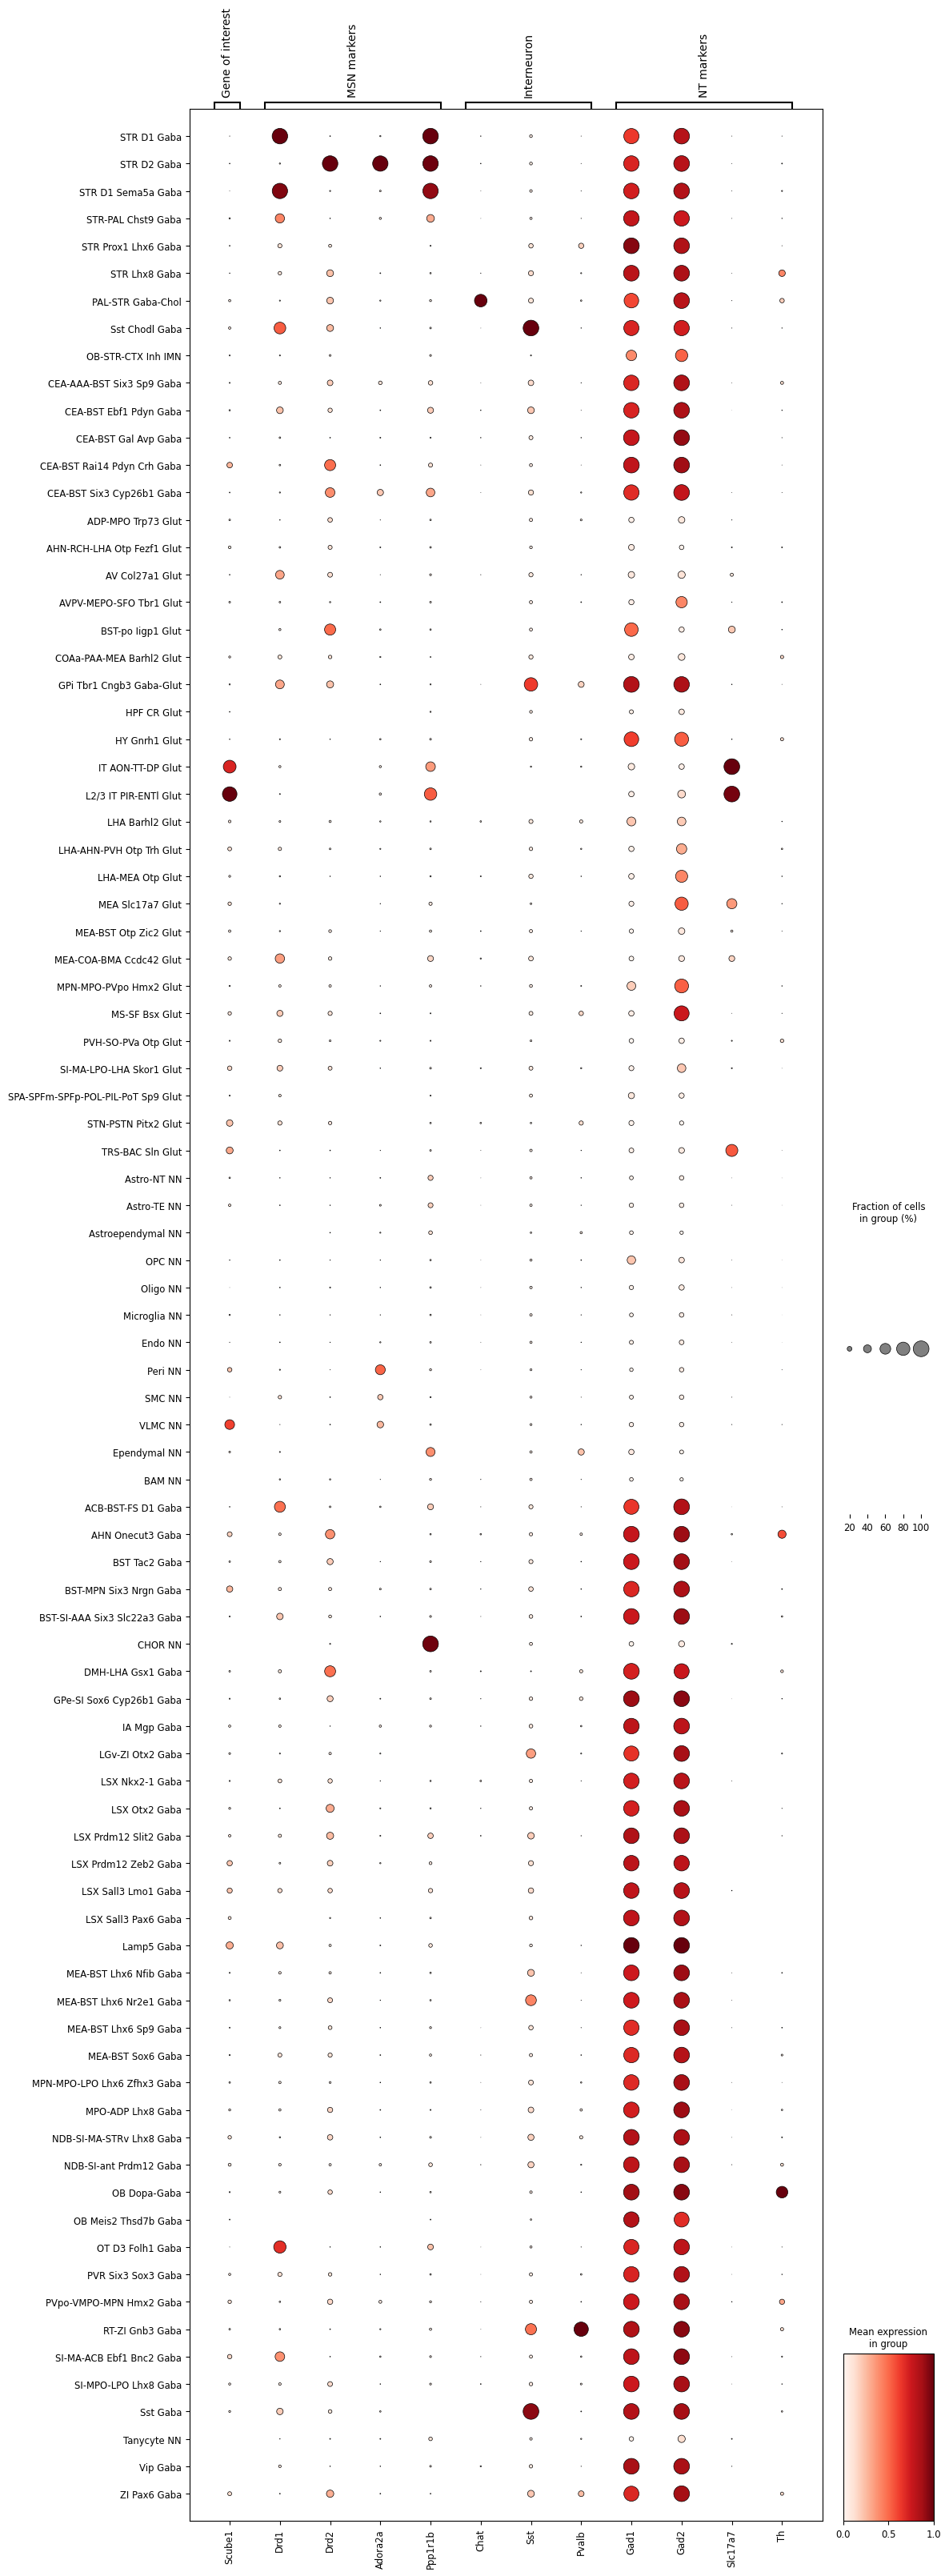

Saved: dotplot_PAL_Scube1_by_subclass.png



In [5]:
def subclass_sort_key(name):
    """Sort subclasses: MSNs > striatal interneurons > pallidal > other neurons > glia."""
    if 'STR D1 Gaba' == name: return (0, name)
    elif 'STR D2 Gaba' == name: return (1, name)
    elif 'STR D1 Sema5a' in name: return (2, name)
    elif 'STR-PAL' in name: return (3, name)
    elif 'STR Prox1' in name: return (4, name)
    elif 'STR Lhx8' in name: return (5, name)
    elif 'PAL-STR' in name: return (6, name)
    elif 'PAL Nkx' in name or 'PAL Gaba' in name: return (7, name)
    elif 'PAL Chol' in name: return (8, name)
    elif 'PAL Glut' in name: return (9, name)
    elif 'PAL' in name and 'Gaba' in name: return (10, name)
    elif 'Sst Chodl' in name: return (11, name)
    elif 'OB-STR' in name: return (12, name)
    elif 'OB-in' in name: return (13, name)
    elif 'OB-out' in name: return (14, name)
    elif 'CEA' in name: return (15, name)
    elif 'L6 CT' in name: return (16, name)
    elif 'L6 IT' in name: return (17, name)
    elif 'LA-BLA' in name: return (18, name)
    elif 'IT EP' in name: return (19, name)
    elif 'Glut' in name: return (20, name)
    elif 'Astro' in name: return (21, name)
    elif 'OPC' in name: return (22, name)
    elif 'Oligo' in name: return (23, name)
    elif 'Micro' in name: return (24, name)
    elif 'Endo' in name: return (25, name)
    elif 'Peri' in name: return (26, name)
    elif 'SMC' in name: return (27, name)
    elif 'VLMC' in name: return (28, name)
    elif 'Ependymal' in name: return (29, name)
    elif 'BAM' in name: return (30, name)
    else: return (31, name)


for region in expr_all:
    meta = meta_all[region]
    expr = expr_all[region]
    
    sc_counts = meta.groupby('subclass_short', observed=True).size()
    valid_sc = sc_counts[sc_counts >= 20].index.tolist()
    sorted_sc = sorted(valid_sc, key=subclass_sort_key)
    
    mask = meta['subclass_short'].isin(valid_sc)
    adata = anndata.AnnData(
        X=expr.loc[mask].values,
        obs=meta.loc[mask][['subclass_short', 'neurotransmitter']].copy(),
        var=pd.DataFrame(index=target_genes)
    )
    adata.obs['subclass_short'] = pd.Categorical(
        adata.obs['subclass_short'], categories=sorted_sc, ordered=True
    )
    
    n_sc = len(sorted_sc)
    dp = sc.pl.dotplot(
        adata,
        var_names=gene_groups,
        groupby='subclass_short',
        standard_scale='var',
        cmap='Reds',
        figsize=(12, max(5, n_sc * 0.45)),
        show=False,
        return_fig=True
    )
    dp.style(dot_edge_color='black', dot_edge_lw=0.5)
    fname = f'dotplot_{region}_Scube1_by_subclass.png'
    dp.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}\n')

## 4. Cross-Region Comparison: Scube1 by Subclass

In [6]:
# Compute Scube1 mean and fraction per subclass per region
summary_rows = []
for region in expr_all:
    meta = meta_all[region]
    expr = expr_all[region]
    sc_counts = meta.groupby('subclass_short', observed=True).size()
    
    for sc_name in sc_counts.index:
        if sc_counts[sc_name] < 20:
            continue
        mask = meta['subclass_short'] == sc_name
        vals = expr.loc[mask, 'Scube1']
        summary_rows.append({
            'region': region,
            'subclass': sc_name,
            'n_cells': len(vals),
            'mean_expr': vals.mean(),
            'frac_expr': (vals > 0).mean(),
        })

scube1_summary = pd.DataFrame(summary_rows)
print(f'Scube1 summary: {len(scube1_summary)} subclass-region combinations')

# Pivot for heatmap
pivot_mean = scube1_summary.pivot(index='subclass', columns='region', values='mean_expr')
pivot_frac = scube1_summary.pivot(index='subclass', columns='region', values='frac_expr')
pivot_n = scube1_summary.pivot(index='subclass', columns='region', values='n_cells')

# Sort by max expression across regions
sort_order = pivot_mean.max(axis=1).sort_values(ascending=True).index
pivot_mean = pivot_mean.loc[sort_order]
pivot_frac = pivot_frac.loc[sort_order]
pivot_n = pivot_n.loc[sort_order]

Scube1 summary: 149 subclass-region combinations


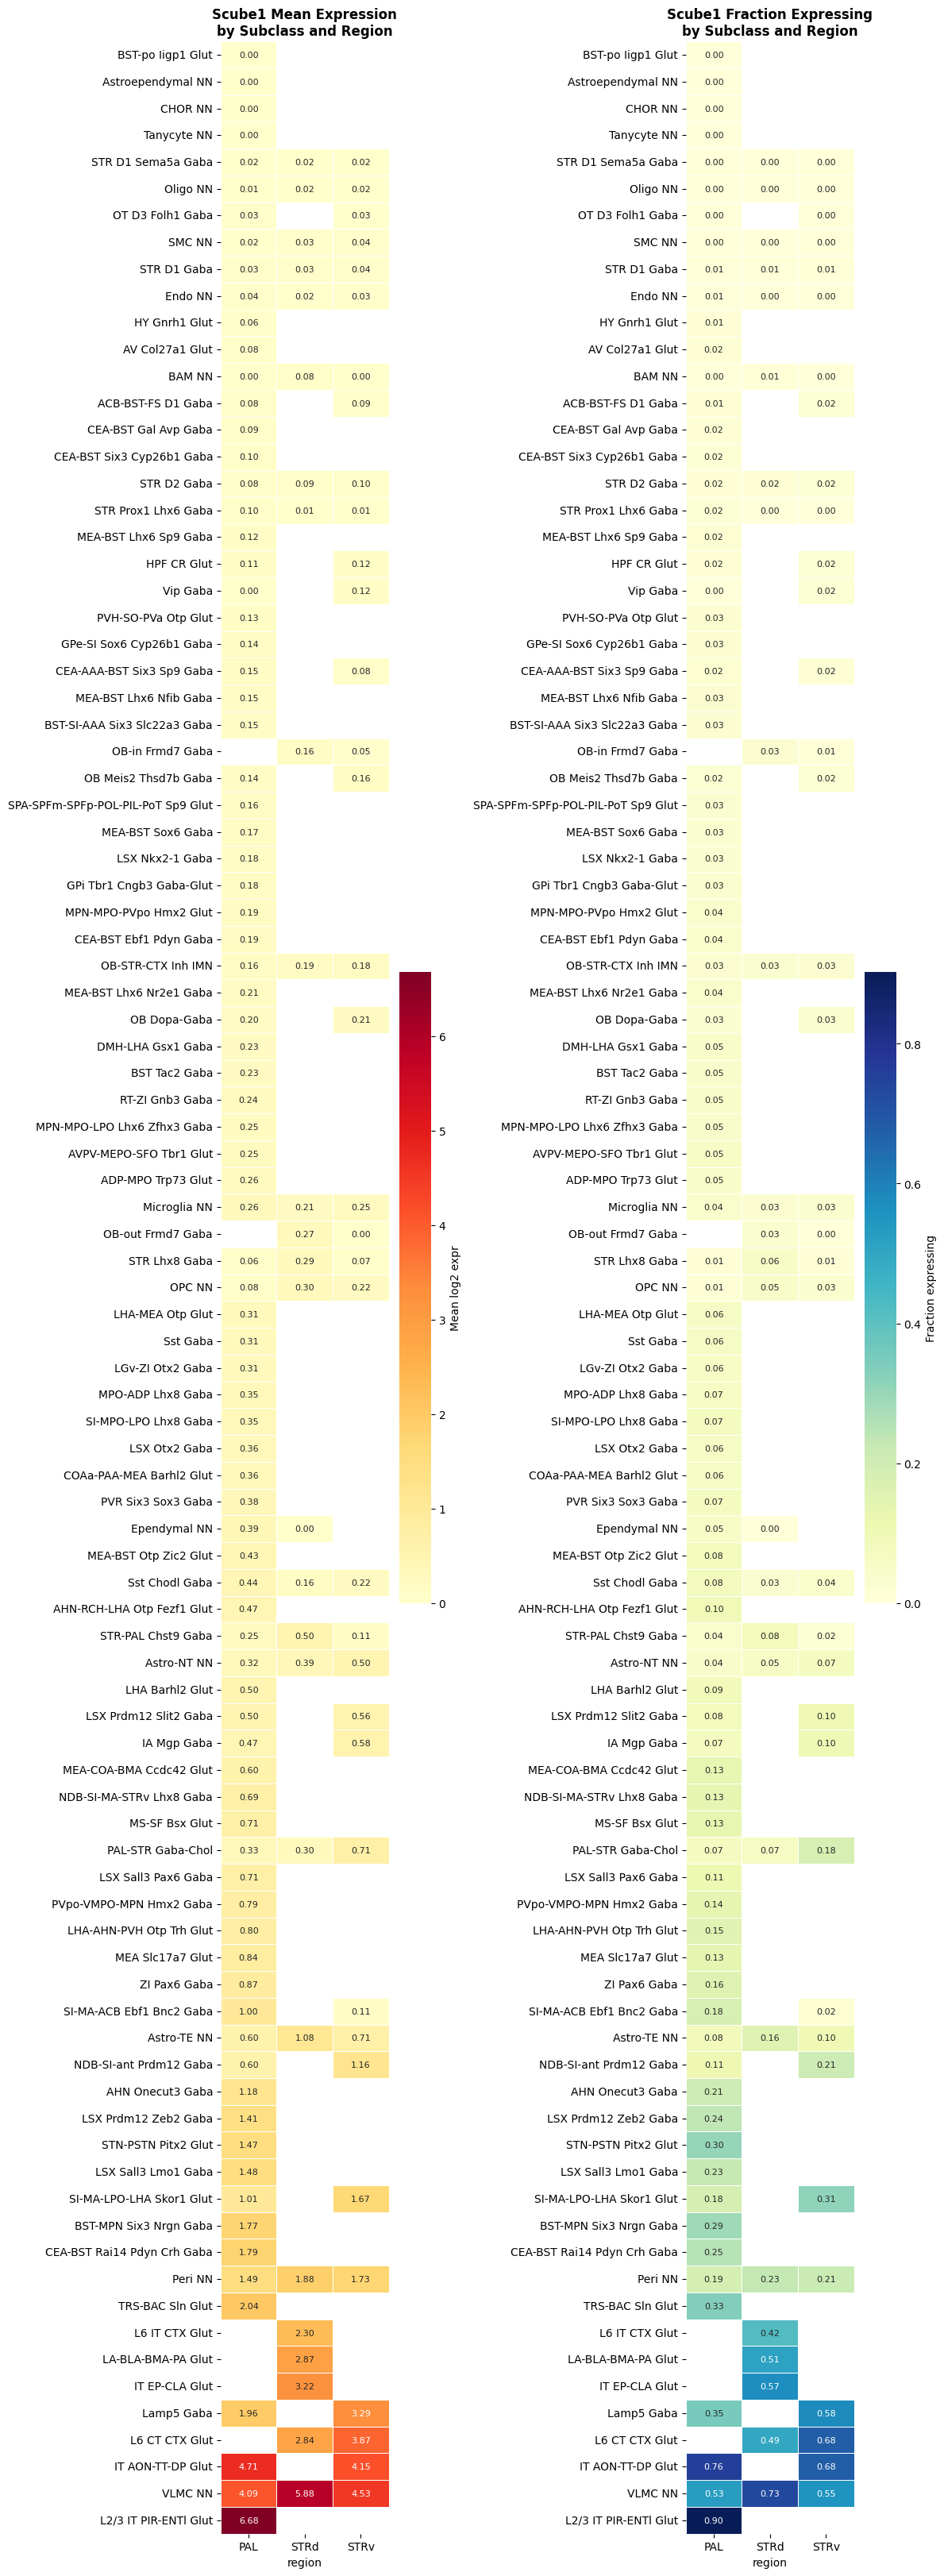

Saved: heatmap_BG_Scube1_cross_region.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, max(6, len(pivot_mean) * 0.35)))

sns.heatmap(pivot_mean, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Mean log2 expr'},
            annot_kws={'size': 8})
axes[0].set_title('Scube1 Mean Expression\nby Subclass and Region', fontweight='bold')
axes[0].set_ylabel('')

sns.heatmap(pivot_frac, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Fraction expressing'},
            annot_kws={'size': 8})
axes[1].set_title('Scube1 Fraction Expressing\nby Subclass and Region', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_BG_Scube1_cross_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_BG_Scube1_cross_region.png')

## 5. Shared Subclasses: Direct Cross-Region Comparison

Subclasses in >= 2 regions: 37


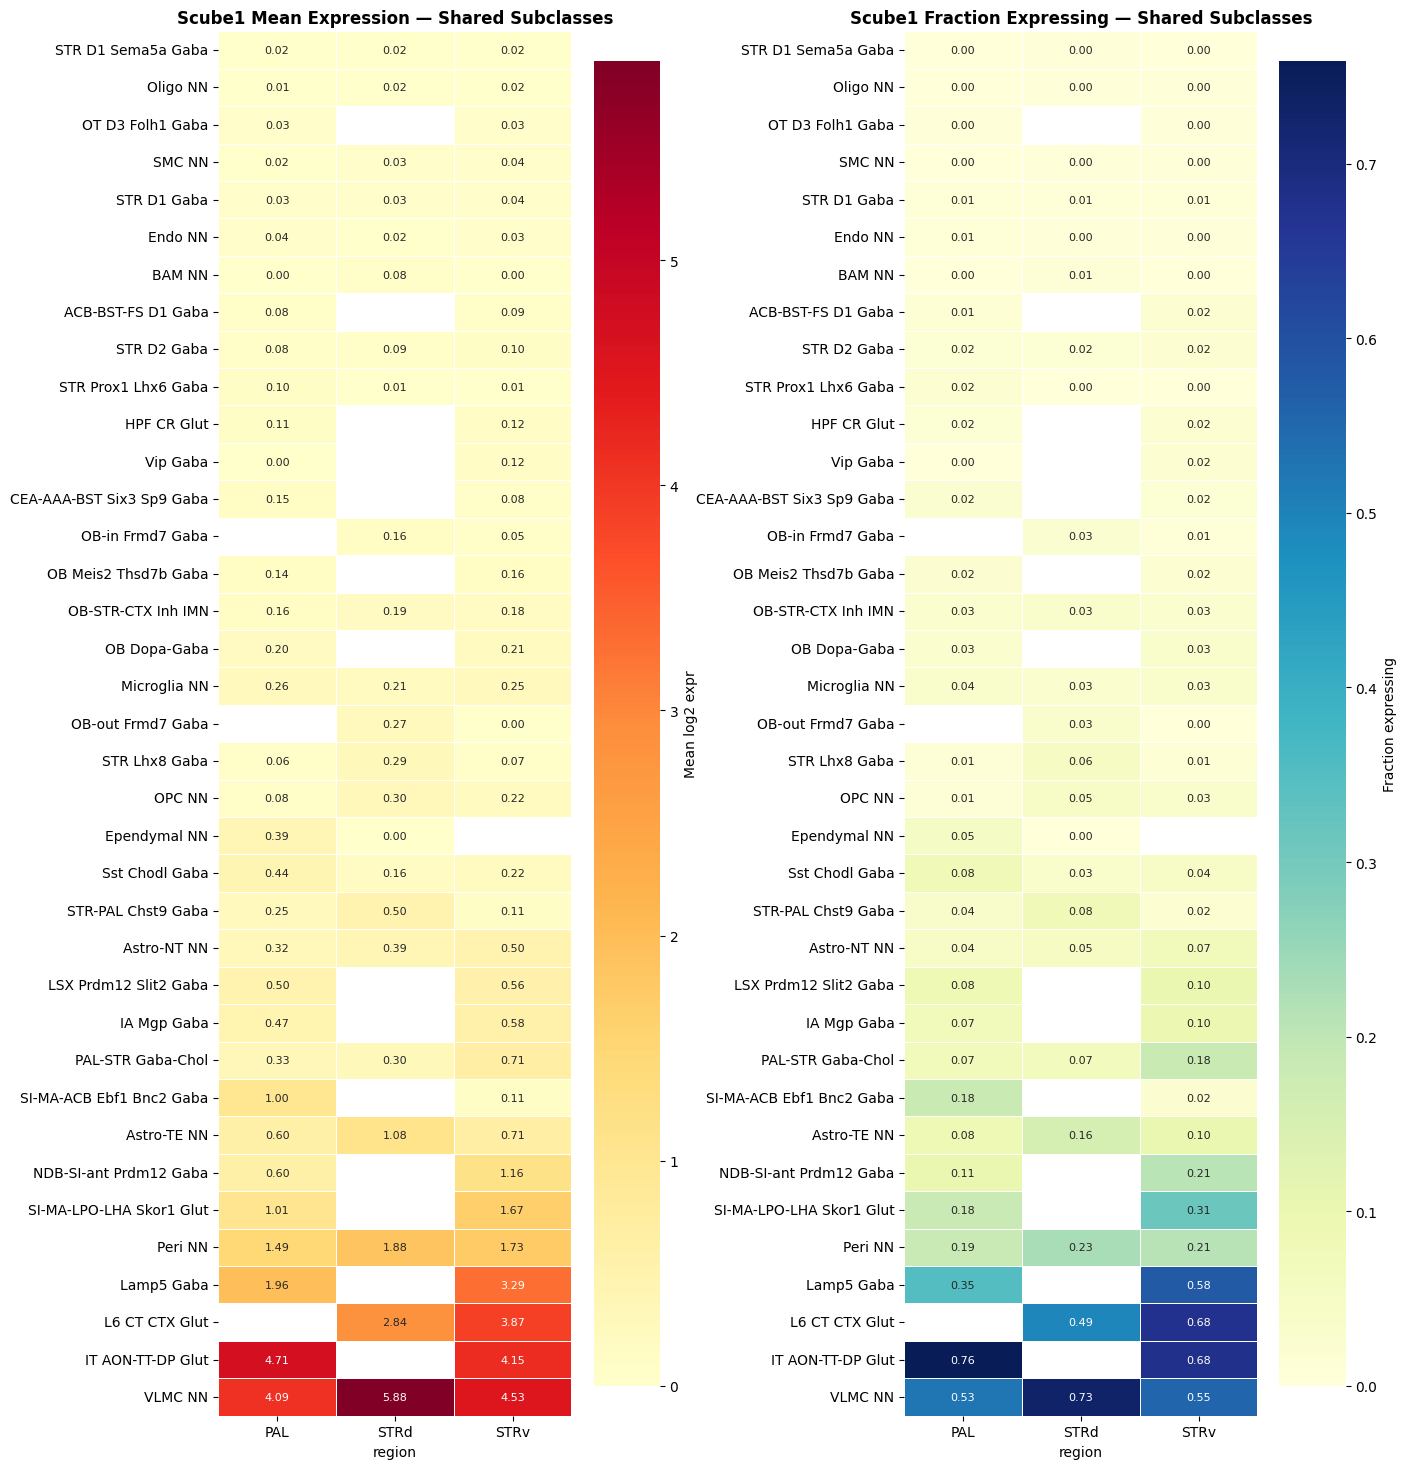

Saved: heatmap_BG_Scube1_shared_subclasses.png


In [8]:
# Find subclasses present in at least 2 regions with >= 20 cells
shared_sc = pivot_mean.dropna(thresh=2).index.tolist()
print(f'Subclasses in >= 2 regions: {len(shared_sc)}')

if len(shared_sc) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(shared_sc) * 0.4)))
    
    shared_mean = pivot_mean.loc[shared_sc]
    shared_frac = pivot_frac.loc[shared_sc]
    
    sns.heatmap(shared_mean, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0],
                linewidths=0.5, cbar_kws={'label': 'Mean log2 expr'},
                annot_kws={'size': 8})
    axes[0].set_title('Scube1 Mean Expression — Shared Subclasses', fontweight='bold')
    axes[0].set_ylabel('')
    
    sns.heatmap(shared_frac, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1],
                linewidths=0.5, cbar_kws={'label': 'Fraction expressing'},
                annot_kws={'size': 8})
    axes[1].set_title('Scube1 Fraction Expressing — Shared Subclasses', fontweight='bold')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.savefig('heatmap_BG_Scube1_shared_subclasses.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: heatmap_BG_Scube1_shared_subclasses.png')
else:
    print('No shared subclasses found across regions.')

## 6. Combined Dot Plot: All Regions, Neuronal Subclasses

Combined: 135,648 cells, 117 region-subclass groups


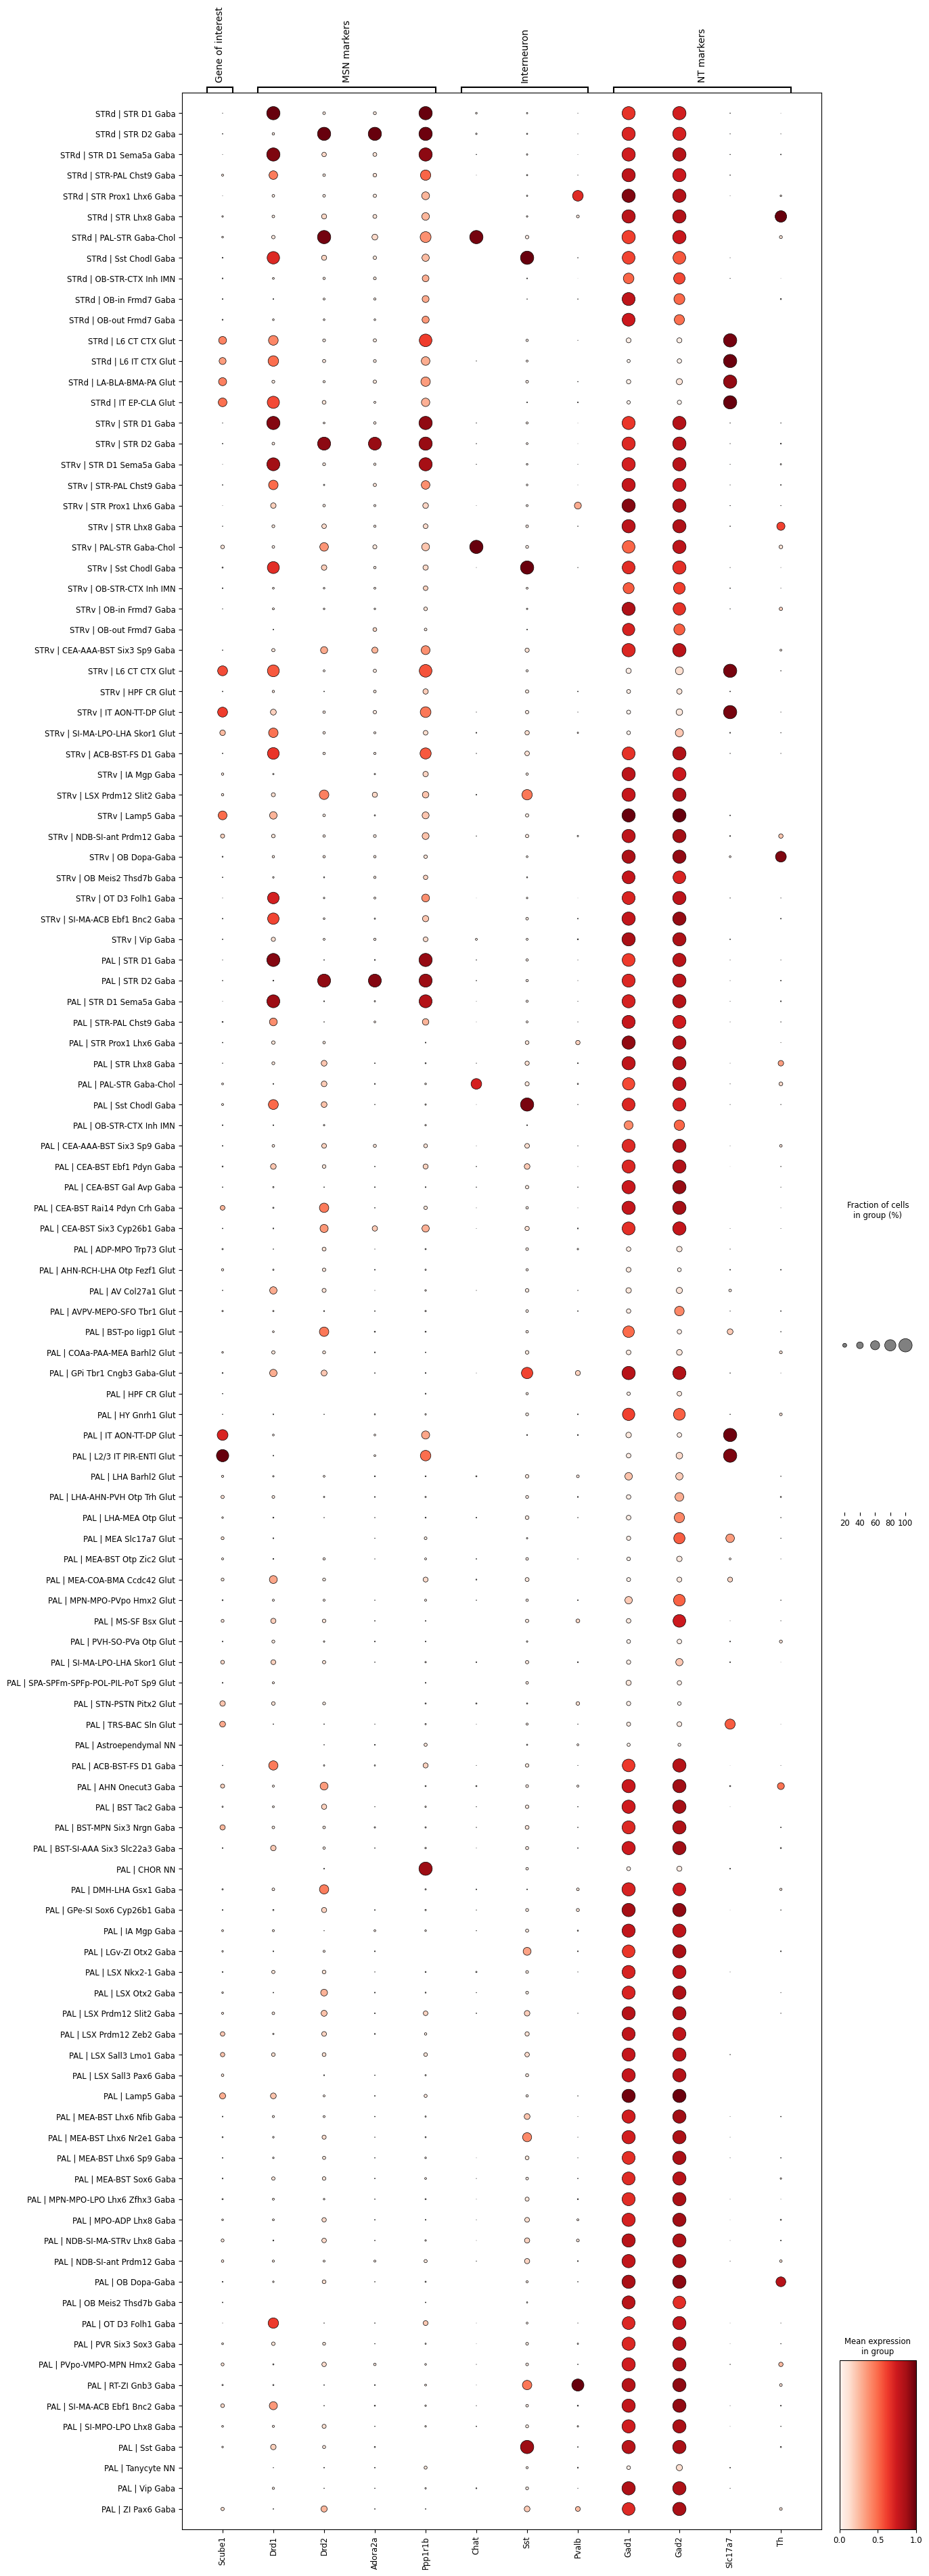

Saved: dotplot_BG_Scube1_all_regions.png


In [9]:
# Combine all regions into one AnnData, tagging region
non_neuronal = {'Astro-TE NN', 'Astro-NT NN', 'OPC NN', 'Oligo NN',
                'Microglia NN', 'Endo NN', 'Peri NN', 'SMC NN',
                'VLMC NN', 'Ependymal NN', 'BAM NN'}

frames_expr = []
frames_meta = []

for region in expr_all:
    meta = meta_all[region].copy()
    expr = expr_all[region]
    
    sc_counts = meta.groupby('subclass_short', observed=True).size()
    valid_neuronal = [s for s in sc_counts[sc_counts >= 20].index
                      if s not in non_neuronal]
    mask = meta['subclass_short'].isin(valid_neuronal)
    meta_sub = meta.loc[mask].copy()
    meta_sub['region'] = region
    meta_sub['region_subclass'] = meta_sub['region'] + ' | ' + meta_sub['subclass_short']
    
    frames_expr.append(expr.loc[mask])
    frames_meta.append(meta_sub)

combined_expr = pd.concat(frames_expr)
combined_meta = pd.concat(frames_meta)

# Sort: group by region, then by subclass sort key within region
region_order = ['STRd', 'STRv', 'PAL']
all_rs = sorted(
    combined_meta['region_subclass'].unique(),
    key=lambda x: (
        region_order.index(x.split(' | ')[0]) if x.split(' | ')[0] in region_order else 99,
        subclass_sort_key(x.split(' | ')[1])
    )
)

adata_combined = anndata.AnnData(
    X=combined_expr.values,
    obs=combined_meta[['region_subclass', 'region', 'subclass_short']].copy(),
    var=pd.DataFrame(index=target_genes)
)
adata_combined.obs['region_subclass'] = pd.Categorical(
    adata_combined.obs['region_subclass'], categories=all_rs, ordered=True
)

n_rs = len(all_rs)
print(f'Combined: {adata_combined.shape[0]:,} cells, {n_rs} region-subclass groups')

dp = sc.pl.dotplot(
    adata_combined,
    var_names=gene_groups,
    groupby='region_subclass',
    standard_scale='var',
    cmap='Reds',
    figsize=(14, max(8, n_rs * 0.4)),
    show=False,
    return_fig=True
)
dp.style(dot_edge_color='black', dot_edge_lw=0.5)
dp.savefig('dotplot_BG_Scube1_all_regions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dotplot_BG_Scube1_all_regions.png')

## 7. Enrichment Heatmap: All Genes Across Regions

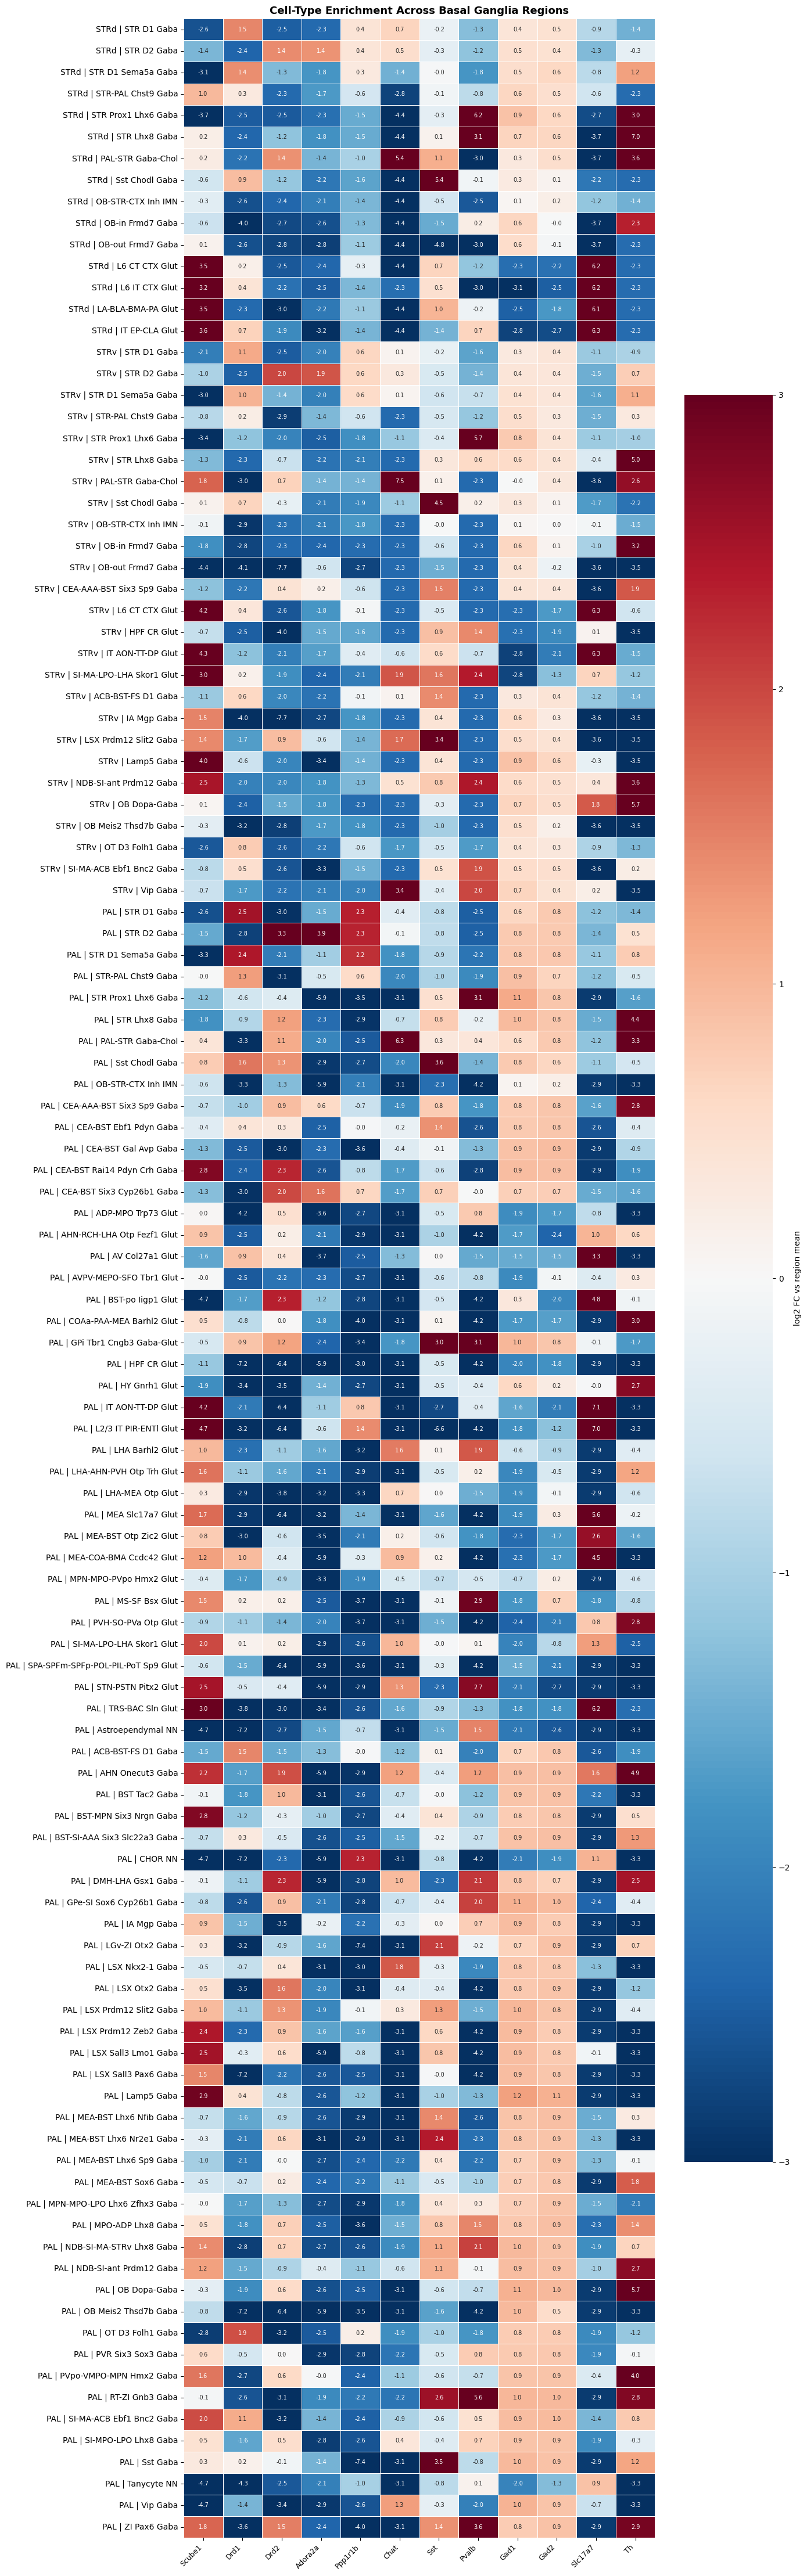

Saved: heatmap_BG_Scube1_enrichment.png


In [10]:
# Compute mean expression per region per subclass for all genes
enrichment_rows = []
for region in expr_all:
    meta = meta_all[region]
    expr = expr_all[region]
    overall_mean = expr[target_genes].mean()
    
    sc_counts = meta.groupby('subclass_short', observed=True).size()
    for sc_name in sc_counts.index:
        if sc_counts[sc_name] < 20:
            continue
        mask = meta['subclass_short'] == sc_name
        sc_mean = expr.loc[mask, target_genes].mean()
        pseudocount = 0.01
        log2fc = np.log2((sc_mean + pseudocount) / (overall_mean + pseudocount))
        row = {'region': region, 'subclass': sc_name}
        for g in target_genes:
            row[g] = log2fc[g]
        enrichment_rows.append(row)

enrich_df = pd.DataFrame(enrichment_rows)
enrich_df['region_subclass'] = enrich_df['region'] + ' | ' + enrich_df['subclass']

# Filter to neuronal
enrich_neuronal = enrich_df[~enrich_df['subclass'].isin(non_neuronal)].copy()
enrich_neuronal = enrich_neuronal.sort_values(
    by='region_subclass',
    key=lambda col: col.map(lambda x: (
        region_order.index(x.split(' | ')[0]) if x.split(' | ')[0] in region_order else 99,
        subclass_sort_key(x.split(' | ')[1])
    ))
)

enrich_mat = enrich_neuronal.set_index('region_subclass')[target_genes]

fig, ax = plt.subplots(figsize=(14, max(8, len(enrich_mat) * 0.38)))
sns.heatmap(enrich_mat, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, vmin=-3, vmax=3,
            cbar_kws={'label': 'log2 FC vs region mean'},
            annot_kws={'size': 7})
ax.set_title('Cell-Type Enrichment Across Basal Ganglia Regions',
             fontweight='bold', fontsize=13)
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_BG_Scube1_enrichment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heatmap_BG_Scube1_enrichment.png')

## 8. Summary Statistics

In [11]:
# Scube1 summary across all regions
print('Scube1 Expression Summary Across Basal Ganglia Regions')
print('=' * 80)

for region in expr_all:
    expr = expr_all[region]
    meta = meta_all[region]
    print(f'\n--- {region} ({len(expr):,} cells) ---')
    print(f'  Overall Scube1 mean: {expr["Scube1"].mean():.3f}')
    print(f'  Overall Scube1 fraction: {(expr["Scube1"] > 0).mean():.3f}')
    
    sc_counts = meta.groupby('subclass_short', observed=True).size()
    for sc_name in sorted(sc_counts[sc_counts >= 50].index, key=subclass_sort_key):
        mask = meta['subclass_short'] == sc_name
        vals = expr.loc[mask, 'Scube1']
        if vals.mean() > 0.1 or (vals > 0).mean() > 0.02:
            print(f'  {sc_name}: mean={vals.mean():.3f}, frac={((vals > 0).mean()):.3f} (n={len(vals):,})')

# Save combined summary
scube1_summary.to_csv('bg_scube1_summary.csv', index=False)
print(f'\nSaved: bg_scube1_summary.csv')

print(f'\n{"=" * 80}')
total = sum(len(e) for e in expr_all.values())
print(f'Total cells across BG regions: {total:,}')
print(f'Regions: {list(expr_all.keys())}')
print(f'Genes: {len(target_genes)}')

Scube1 Expression Summary Across Basal Ganglia Regions

--- STRd (55,626 cells) ---
  Overall Scube1 mean: 0.248
  Overall Scube1 fraction: 0.038
  STR-PAL Chst9 Gaba: mean=0.498, frac=0.082 (n=437)
  STR Lhx8 Gaba: mean=0.287, frac=0.056 (n=178)
  Sst Chodl Gaba: mean=0.162, frac=0.030 (n=230)
  OB-STR-CTX Inh IMN: mean=0.194, frac=0.030 (n=1,642)
  OB-in Frmd7 Gaba: mean=0.156, frac=0.026 (n=77)
  L6 CT CTX Glut: mean=2.840, frac=0.494 (n=172)
  L6 IT CTX Glut: mean=2.302, frac=0.422 (n=116)
  LA-BLA-BMA-PA Glut: mean=2.869, frac=0.513 (n=76)
  Astro-NT NN: mean=0.390, frac=0.054 (n=111)
  Astro-TE NN: mean=1.081, frac=0.156 (n=6,190)
  OPC NN: mean=0.304, frac=0.047 (n=1,331)
  Microglia NN: mean=0.212, frac=0.028 (n=2,277)
  Peri NN: mean=1.876, frac=0.230 (n=556)
  VLMC NN: mean=5.883, frac=0.730 (n=148)

--- STRv (53,573 cells) ---
  Overall Scube1 mean: 0.201
  Overall Scube1 fraction: 0.032
  STR-PAL Chst9 Gaba: mean=0.108, frac=0.018 (n=1,349)
  PAL-STR Gaba-Chol: mean=0.709, 

  NDB-SI-ant Prdm12 Gaba: mean=1.156, frac=0.208 (n=96)
  OB Meis2 Thsd7b Gaba: mean=0.160, frac=0.019 (n=52)


  Vip Gaba: mean=0.123, frac=0.020 (n=51)

--- PAL (108,046 cells) ---
  Overall Scube1 mean: 0.252
  Overall Scube1 fraction: 0.042
  STR-PAL Chst9 Gaba: mean=0.248, frac=0.038 (n=4,603)
  STR Prox1 Lhx6 Gaba: mean=0.101, frac=0.018 (n=219)
  PAL-STR Gaba-Chol: mean=0.334, frac=0.074 (n=784)
  Sst Chodl Gaba: mean=0.435, frac=0.080 (n=960)
  CEA-AAA-BST Six3 Sp9 Gaba: mean=0.149, frac=0.024 (n=1,155)
  CEA-BST Ebf1 Pdyn Gaba: mean=0.194, frac=0.038 (n=1,761)
  CEA-BST Rai14 Pdyn Crh Gaba: mean=1.786, frac=0.251 (n=303)
  ADP-MPO Trp73 Glut: mean=0.259, frac=0.048 (n=291)
  AVPV-MEPO-SFO Tbr1 Glut: mean=0.252, frac=0.051 (n=253)
  COAa-PAA-MEA Barhl2 Glut: mean=0.361, frac=0.062 (n=96)
  GPi Tbr1 Cngb3 Gaba-Glut: mean=0.176, frac=0.033 (n=329)
  HPF CR Glut: mean=0.109, frac=0.016 (n=61)
  LHA Barhl2 Glut: mean=0.503, frac=0.090 (n=167)
  LHA-AHN-PVH Otp Trh Glut: mean=0.802, frac=0.153 (n=144)
  LHA-MEA Otp Glut: mean=0.306, frac=0.061 (n=82)
  MEA Slc17a7 Glut: mean=0.838, frac=0.134

  MS-SF Bsx Glut: mean=0.705, frac=0.134 (n=336)
  SI-MA-LPO-LHA Skor1 Glut: mean=1.015, frac=0.185 (n=3,353)
  TRS-BAC Sln Glut: mean=2.038, frac=0.332 (n=602)
  Astro-NT NN: mean=0.318, frac=0.044 (n=8,066)
  Astro-TE NN: mean=0.601, frac=0.085 (n=2,284)
  Microglia NN: mean=0.261, frac=0.035 (n=2,992)
  Peri NN: mean=1.485, frac=0.185 (n=535)
  VLMC NN: mean=4.090, frac=0.526 (n=173)
  BST Tac2 Gaba: mean=0.232, frac=0.045 (n=705)
  BST-MPN Six3 Nrgn Gaba: mean=1.773, frac=0.289 (n=799)
  BST-SI-AAA Six3 Slc22a3 Gaba: mean=0.150, frac=0.028 (n=575)
  GPe-SI Sox6 Cyp26b1 Gaba: mean=0.141, frac=0.028 (n=1,106)
  IA Mgp Gaba: mean=0.467, frac=0.073 (n=96)
  LSX Nkx2-1 Gaba: mean=0.176, frac=0.030 (n=300)
  LSX Otx2 Gaba: mean=0.356, frac=0.062 (n=306)
  LSX Prdm12 Slit2 Gaba: mean=0.496, frac=0.084 (n=119)
  LSX Prdm12 Zeb2 Gaba: mean=1.408, frac=0.237 (n=59)
  LSX Sall3 Lmo1 Gaba: mean=1.483, frac=0.226 (n=84)
  LSX Sall3 Pax6 Gaba: mean=0.713, frac=0.109 (n=64)
  Lamp5 Gaba: mean=1.9

  MPO-ADP Lhx8 Gaba: mean=0.349, frac=0.066 (n=1,002)
  NDB-SI-MA-STRv Lhx8 Gaba: mean=0.692, frac=0.135 (n=5,327)
  NDB-SI-ant Prdm12 Gaba: mean=0.603, frac=0.107 (n=985)
  OB Dopa-Gaba: mean=0.205, frac=0.029 (n=69)
  PVR Six3 Sox3 Gaba: mean=0.380, frac=0.071 (n=605)
  PVpo-VMPO-MPN Hmx2 Gaba: mean=0.790, frac=0.136 (n=184)
  RT-ZI Gnb3 Gaba: mean=0.240, frac=0.048 (n=436)
  SI-MA-ACB Ebf1 Bnc2 Gaba: mean=1.004, frac=0.182 (n=1,164)
  SI-MPO-LPO Lhx8 Gaba: mean=0.349, frac=0.069 (n=1,071)
  ZI Pax6 Gaba: mean=0.871, frac=0.157 (n=108)

Saved: bg_scube1_summary.csv

Total cells across BG regions: 217,245
Regions: ['STRd', 'STRv', 'PAL']
Genes: 12
